# **Final Project Notebook**

### Zoe Kirkman & Madison Engebose

## Research Question
How do different features relate to burnout in technical workers that use AI for thier jobs?

## Hypothesis
1. Different remote work types have different levels of burnout.
2. Employees who spend more hours with AI assistance will experience higher burnout. 
3. More weekly AI upskilling hours are associated with lower burnout
4. High attrition risk increases burnout
5. Employees with higher fear of AI replacement have higher burnout scores. 

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Dataset 
The dataset we are using looks at features related to job type and function, AI use within the job, and employee feelings about AI with respect to their jobs. The dataset was created synthetically using the patterns described in the following studies: Microsoft's 2025 Work Trend Index, Stack Overflow Developer Survey 2024-2025, Gallup Workplace Burnout Studies, LinkedIn Workforce Confidence Reports, and World Economic Forum Future of Jobs Report 2025.   
Why dataset was created
Who created it
Explanation of features and target variables 
references to dataset

In [141]:
df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')
df.head(10)

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
5,EMP0006,Data Analyst,12,Self-taught,Germany,Healthtech,Large (1000-5000),On-site,19,106,...,5,5.7,23,Optimizing,6.7,66,61,3.5,Medium,Low
6,EMP0007,AI Ethics Officer,12,PhD,USA,Gaming,Enterprise (5000+),Fully Remote,46,154,...,1,2.7,45,Optimizing,8.1,54,33,3.5,High,Low
7,EMP0008,Data Scientist,19,Bootcamp,Singapore,Consulting,Enterprise (5000+),Hybrid,44,54,...,7,4.7,46,Optimizing,9.1,43,57,2.9,Low,Medium
8,EMP0009,Data Analyst,6,Master,Germany,Fintech,Mid (200-1000),Hybrid,42,55,...,7,2.8,56,Experimenting,8.1,69,52,2.8,Low,Medium
9,EMP0010,Prompt Engineer,2,Bachelor,Netherlands,Gaming,Large (1000-5000),On-site,15,61,...,5,1.8,8,Optimizing,9.7,64,27,3.8,Medium,Low


In [142]:
df.dtypes

employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object

In [143]:
nominal_cats = [
    "job_role", "education_level", "country",
    "industry", "company_size", "remote_work_type", "primary_ai_tool",
]
for col in nominal_cats:
    df[col] = df[col].astype("category")

In [144]:
df["fear_of_ai_replacement"] = pd.Categorical(
    df["fear_of_ai_replacement"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
df["attrition_risk"] = pd.Categorical(
    df["attrition_risk"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
df["ai_adoption_stage"] = pd.Categorical(
    df["ai_adoption_stage"],
    categories=["Experimenting", "Integrating", "Optimizing", "AI-First"],
    ordered=True,
)

In [145]:
df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [146]:
df.dtypes

employee_id                         object
job_role                          category
years_experience                     int64
education_level                   category
country                           category
industry                          category
company_size                      category
remote_work_type                  category
team_size                            int64
salary_usd_k                         int64
primary_ai_tool                   category
ai_tools_used_per_day                int64
hours_with_ai_assistance_daily     float64
ai_replaces_my_tasks_pct             int64
ai_adoption_stage                 category
weekly_ai_upskilling_hrs           float64
productivity_score                   int64
burnout_score                        int64
job_satisfaction_1_5               float64
fear_of_ai_replacement            category
attrition_risk                    category
dtype: object

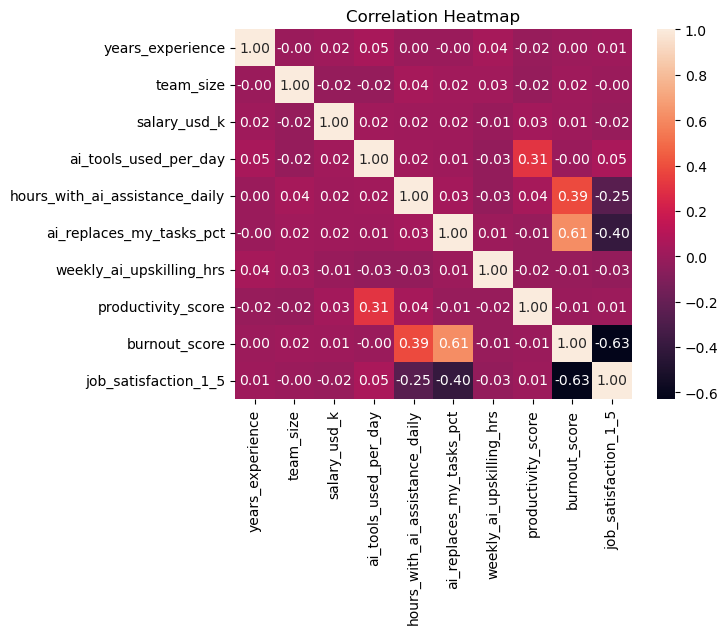

In [147]:
plt.figure()
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Burnout by Remote Work Type

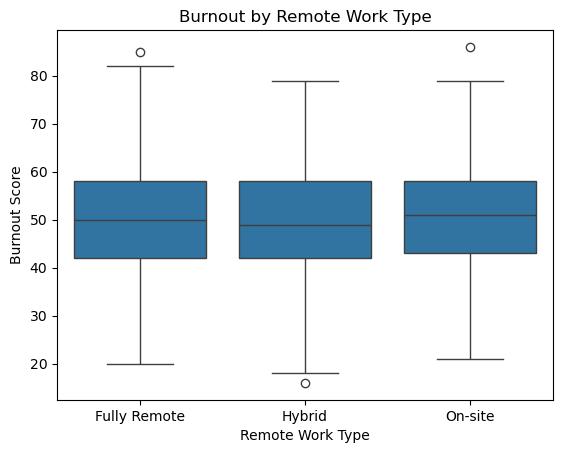

In [148]:
plt.figure()
sns.boxplot(x="remote_work_type", y="burnout_score", data=df)
plt.title("Burnout by Remote Work Type")
plt.xlabel("Remote Work Type")
plt.ylabel("Burnout Score")
plt.show()

### AI Replacing Tasks vs Burnout

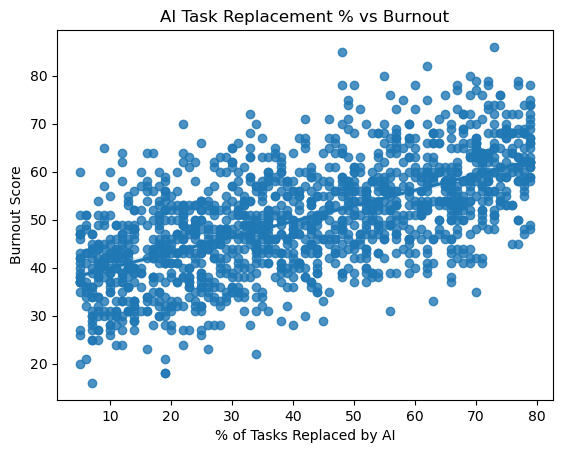

In [149]:
plt.figure()
sns.regplot(x="ai_replaces_my_tasks_pct", y="burnout_score", data=df)
plt.title("AI Task Replacement % vs Burnout")
plt.xlabel("% of Tasks Replaced by AI")
plt.ylabel("Burnout Score")
plt.show()

### Daily AI Hours vs Burnout

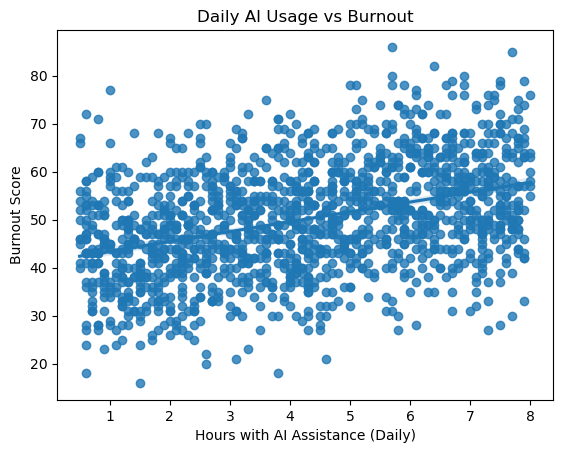

In [150]:
plt.figure()
sns.regplot(x="hours_with_ai_assistance_daily", y="burnout_score", data=df)
plt.title("Daily AI Usage vs Burnout")
plt.xlabel("Hours with AI Assistance (Daily)")
plt.ylabel("Burnout Score")
plt.show()

### AI Upskilling vs Burnout

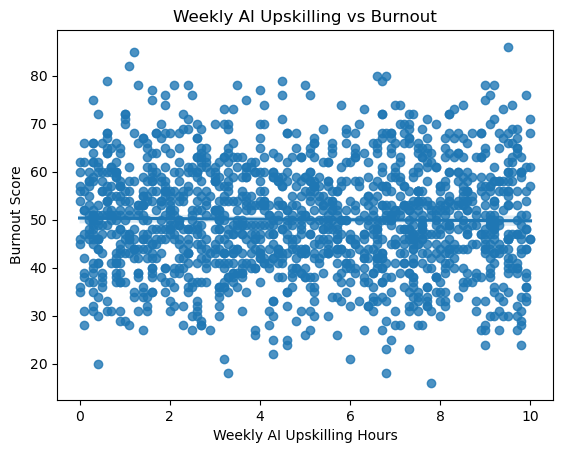

In [151]:
plt.figure()
sns.regplot(x="weekly_ai_upskilling_hrs", y="burnout_score", data=df)
plt.title("Weekly AI Upskilling vs Burnout")
plt.xlabel("Weekly AI Upskilling Hours")
plt.ylabel("Burnout Score")
plt.show()

### Fear of AI Replacement vs Burnout

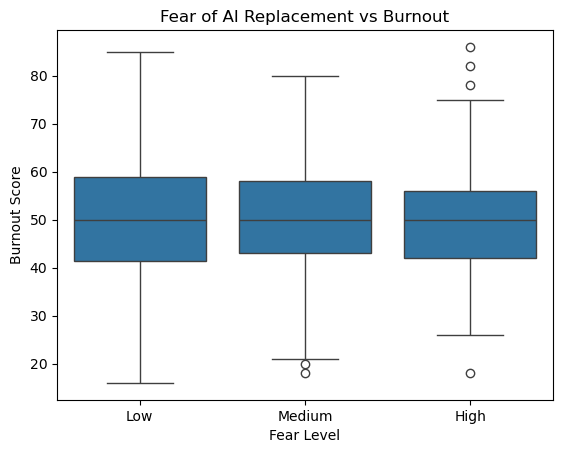

In [152]:
plt.figure()
sns.boxplot(x="fear_of_ai_replacement", y="burnout_score", data=df)
plt.title("Fear of AI Replacement vs Burnout")
plt.xlabel("Fear Level")
plt.ylabel("Burnout Score")
plt.show()

### Burnout vs Attrition Risk

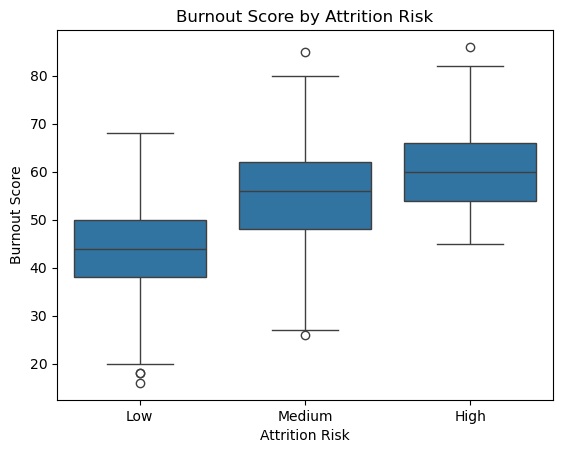

In [153]:
plt.figure()
sns.boxplot(x="attrition_risk", y="burnout_score", data=df)
plt.title("Burnout Score by Attrition Risk")
plt.xlabel("Attrition Risk")
plt.ylabel("Burnout Score")
plt.show()

### Productivity vs Burnout

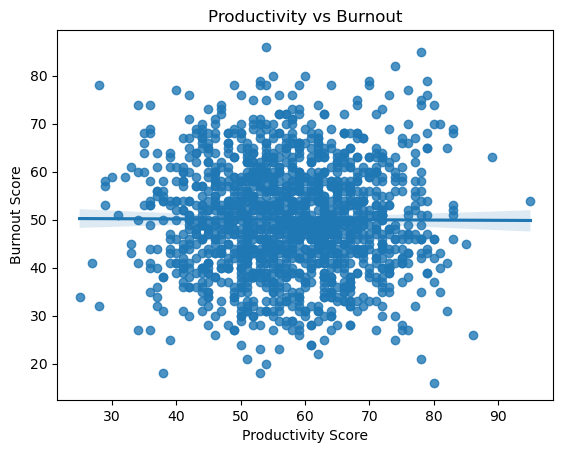

In [154]:
plt.figure()
sns.regplot(x="productivity_score", y="burnout_score", data=df)
plt.title("Productivity vs Burnout")
plt.xlabel("Productivity Score")
plt.ylabel("Burnout Score")
plt.show()

### Productivity vs Attrition Risk

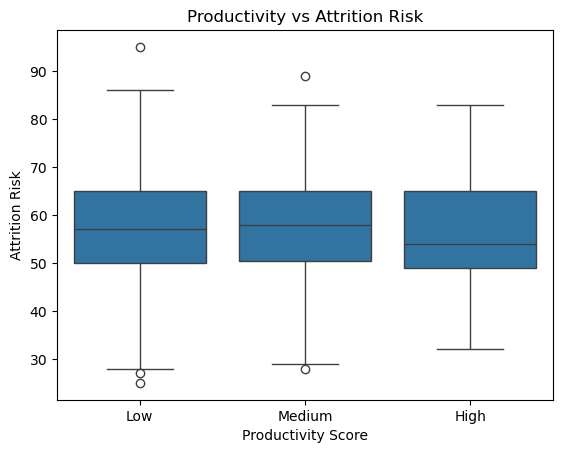

In [155]:
plt.figure()
sns.boxplot(x="attrition_risk", y="productivity_score", data=df)
plt.title("Productivity vs Attrition Risk")
plt.xlabel("Productivity Score")
plt.ylabel("Attrition Risk")
plt.show()

### Job Satisfaction vs Burnout

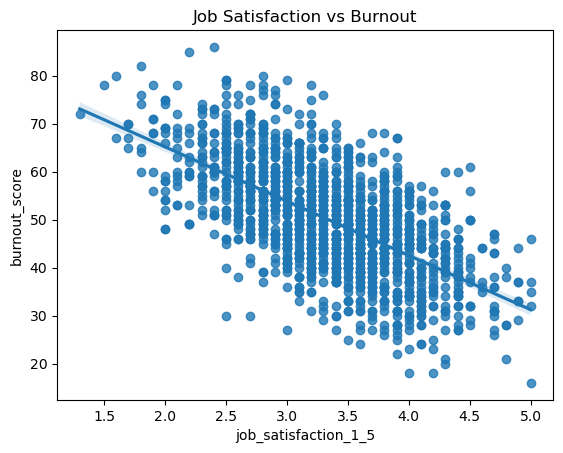

In [156]:
plt.figure()
sns.regplot(x="job_satisfaction_1_5", y="burnout_score", data=df)
plt.title("Job Satisfaction vs Burnout")
plt.show()

### Linear Regression Models

sklearn:

In [157]:
regression_model = LinearRegression()
independent_cols = pd.DataFrame(df.select_dtypes(include="number"))
independent_cols = independent_cols.drop("burnout_score", axis =1)
y = df["burnout_score"]

X_train, X_test, y_train, y_test = train_test_split(independent_cols, y, test_size=0.3, random_state=27)

results = regression_model.fit(X_train, y_train)
for i in range(len(X_train.columns)):
    print(f"{X_train.columns[i]}: {results.coef_[i]:.4f}")
    


years_experience: 0.0400
team_size: -0.0025
salary_usd_k: -0.0019
ai_tools_used_per_day: 0.0821
hours_with_ai_assistance_daily: 1.4738
ai_replaces_my_tasks_pct: 0.2500
weekly_ai_upskilling_hrs: -0.0716
productivity_score: -0.0272
job_satisfaction_1_5: -6.7845


Statsmodel API

This model uses all numerical values without any categorical variables being encoded

In [158]:
import statsmodels.api as sm

X = sm.add_constant(X_train)
linear_model = sm.OLS(y_train, X).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     198.6
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          8.20e-219
Time:                        09:31:25   Log-Likelihood:                -3528.8
No. Observations:                1050   AIC:                             7078.
Df Residuals:                    1040   BIC:                             7127.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

The following linear regression model only has the predictors that are statistically significant and it has the same ajusted R-squared value so the other variables were not helpful. 
This model uses hours_with_ai_assistance, ai_replaces_my_tasks_pct, job_satisfaction_1_5 as predictors 

In [159]:
significant_predictors = X_train.columns[linear_model.pvalues[1:] < 0.05]
X = sm.add_constant(X_train[significant_predictors])
refined_model = sm.OLS(y_train, X).fit()
print(refined_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     595.4
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.14e-225
Time:                        09:31:25   Log-Likelihood:                -3530.9
No. Observations:                1050   AIC:                             7070.
Df Residuals:                    1046   BIC:                             7090.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

Using one hot encoding to add categorical variables to be used in the linear regression model. Including education_level, remote_work_type, fear_of_ai_replacement, and attrition_risk

In [160]:
# One hot encoding education level 
df["formal_education"] = df["education_level"].apply(lambda x: 1 if x in ["Bachelor", "Masters", "PhD"] else 0)
df["masters_phd"] = df["education_level"].apply(lambda x: 1 if x in ["Masters", "PhD"] else 0)

# Remote work type encoding
df["is_hybrid"] = df["remote_work_type"].apply(lambda x: 1 if x == "Hybrid" else 0)
df["is_remote"] = df["remote_work_type"].apply(lambda x: 1 if x == "Remote" else 0)
df["is_on_site"] = df["remote_work_type"].apply(lambda x: 1 if x == "On Site" else 0)

# Fear of AI Replacement encoding
df["fear_low"] = df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "Low" else 0)
df["fear_medium"] = df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "Medium" else 0)
df["fear_high"] = df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "High" else 0)

# Attrition risk encoding
df["attrition_low"] = df["attrition_risk"].apply(lambda x: 1 if x == "Low" else 0)
df["attrition_medium"] = df["attrition_risk"].apply(lambda x: 1 if x == "Medium" else 0)
df["attrition_high"] = df["attrition_risk"].apply(lambda x: 1 if x == "High" else 0)

df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,masters_phd,is_hybrid,is_remote,is_on_site,fear_low,fear_medium,fear_high,attrition_low,attrition_medium,attrition_high
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0,0,0,1,0,0,0,1,0
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,0,1,0,0,0,1,0,0,1,0
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,1,1,0,0,0,0,1,0,1,0
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,0,0,0,0,1,0,0,0,1,0
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,0,0,0,0,0,1,0,0,1,0


In [161]:
independent_cols = pd.DataFrame(df.select_dtypes(include="number"))
independent_cols = independent_cols.drop("burnout_score", axis =1)
y = df["burnout_score"]
X_train, X_test, y_train, y_test = train_test_split(independent_cols, y, test_size=0.3, random_state=27)


X = sm.add_constant(X_train)
one_hot_encoding_model = sm.OLS(y_train, X).fit()
print(one_hot_encoding_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     131.1
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          2.65e-235
Time:                        09:31:25   Log-Likelihood:                -3471.8
No. Observations:                1050   AIC:                             6978.
Df Residuals:                    1033   BIC:                             7062.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [162]:
significant_predictors = X_train.columns[one_hot_encoding_model.pvalues[1:] < 0.05]
X = sm.add_constant(X_train[significant_predictors])
new_refined_model = sm.OLS(y_train, X).fit()
print(new_refined_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     299.7
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.77e-244
Time:                        09:31:25   Log-Likelihood:                -3474.7
No. Observations:                1050   AIC:                             6965.
Df Residuals:                    1042   BIC:                             7005.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [163]:
from sklearn.metrics import mean_squared_error

#baseline model
independent_cols = pd.DataFrame(df.select_dtypes(include="number"))
independent_cols = independent_cols.drop("burnout_score", axis =1)
y = df["burnout_score"]

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(independent_cols, y, test_size=0.3, random_state=27)

regression_model = regression_model.fit(X_train_baseline, y_train_baseline)
y_pred_baseline = regression_model.predict(X_test_baseline)
print(mean_squared_error(y_test_baseline, y_pred_baseline))


#best model 
significant_predictors = X_train.columns[one_hot_encoding_model.pvalues[1:] < 0.05]
X = sm.add_constant(X_train[significant_predictors])
new_refined_model = sm.OLS(y_train, X).fit()
y_pred = new_refined_model.predict(sm.add_constant(X_test[significant_predictors]))
print(mean_squared_error(y_test, y_pred))



49.42786112305762
49.39137065656077
